In [1]:
import sys
!{sys.executable} -m pip install scikit-learn

# Week 1 · Day 5 Mini-Project
## Exploratory Data Analysis — Diabetes Dataset

**Dataset:** Pima Indians Diabetes Dataset (via `sklearn.datasets`)

**Goal:** Load the dataset, clean it, compute summary statistics, produce 3 informative plots, and write a short paragraph summarising findings.

**Skills practised:** `pandas`, `numpy`, `matplotlib`, data loading, `.describe()`, histograms, scatter plots, box plots.

# 1. Load the Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Reproducibility
np.random.seed(42)

# -----------------------------------------------------------------------
# Option A (used here): load directly from sklearn — no download needed.
# Option B: df = pd.read_csv('diabetes.csv')  — downloaded from Kaggle.
# -----------------------------------------------------------------------
from sklearn.datasets import load_diabetes

raw = load_diabetes()
df = pd.DataFrame(raw.data, columns=raw.feature_names)
df['disease_progression'] = raw.target   # continuous target: disease severity after 1 year

print(f'Shape: {df.shape}')              # rows × columns
df.head()

Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


**Note on the columns:** sklearn's version normalises all features to zero mean, unit variance.
- `age`, `sex`, `bmi`, `bp` — demographics and body measurements  
- `s1–s6` — six blood serum measurements (cholesterol, LDL, HDL, etc.)  
- `disease_progression` — quantitative measure of disease severity one year after baseline (our target)

In [4]:
# ---- 2a. Basic info -------------------------------------------------------
print('=== dtypes ===')
print(df.dtypes)
print()

# ---- 2b. Missing values ---------------------------------------------------
missing = df.isnull().sum()
print('=== Missing values per column ===')
print(missing)
print(f'\nTotal missing cells: {missing.sum()}')

=== dtypes ===
age                    float64
sex                    float64
bmi                    float64
bp                     float64
s1                     float64
s2                     float64
s3                     float64
s4                     float64
s5                     float64
s6                     float64
disease_progression    float64
dtype: object

=== Missing values per column ===
age                    0
sex                    0
bmi                    0
bp                     0
s1                     0
s2                     0
s3                     0
s4                     0
s5                     0
s6                     0
disease_progression    0
dtype: int64

Total missing cells: 0


In [5]:
# ---- 2c. Check for duplicates ---------------------------------------------
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes}')

# This dataset is already clean but the check is good practice.
# In a real clinical dataset I would also:
#   - verify plausible value ranges (e.g. BMI between 10 and 80)
#   - handle zero-coded missing values (common in older medical CSVs)

Duplicate rows: 0


---
## 3. Summary Statistics

In [6]:
# pandas .describe() gives count, mean, std, min, quartiles, max
df.describe().round(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


In [7]:
print(f"Sample size         : {len(df)} patients")
print(f"Target mean         : {df['disease_progression'].mean():.1f}")
print(f"Target std          : {df['disease_progression'].std():.1f}")
print(f"Target range        : {df['disease_progression'].min():.0f} – {df['disease_progression'].max():.0f}")
print()
print("Correlation with disease_progression (top 4):")
print(df.corr()['disease_progression'].drop('disease_progression').abs().sort_values(ascending=False).head(4).round(3))

Sample size         : 442 patients
Target mean         : 152.1
Target std          : 77.1
Target range        : 25 – 346

Correlation with disease_progression (top 4):
bmi    0.586
s5     0.566
bp     0.441
s4     0.430
Name: disease_progression, dtype: float64


---
## 4. Plots
### Plot 1 — Distribution of Disease Progression (target variable)

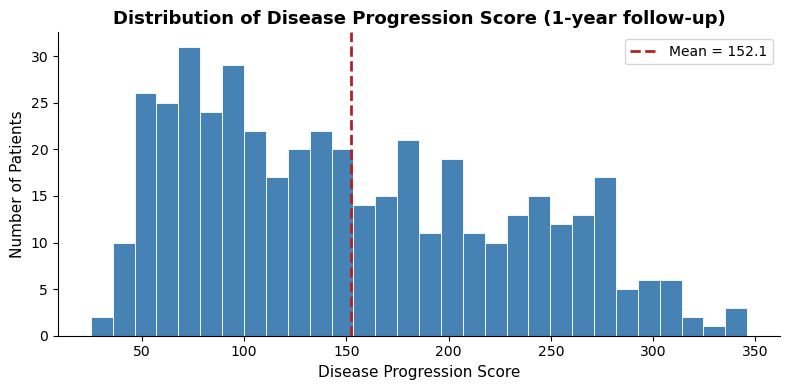

Saved: plot1_target_distribution.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['disease_progression'], bins=30, color='steelblue', edgecolor='white', linewidth=0.6)

# Add mean line
mean_val = df['disease_progression'].mean()
ax.axvline(mean_val, color='firebrick', linewidth=2, linestyle='--', label=f'Mean = {mean_val:.1f}')

ax.set_title('Distribution of Disease Progression Score (1-year follow-up)', fontsize=13, fontweight='bold')
ax.set_xlabel('Disease Progression Score', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot1_target_distribution.png', dpi=150)
plt.show()
print('Saved: plot1_target_distribution.png')

### Plot 2 — BMI vs Disease Progression (scatter)

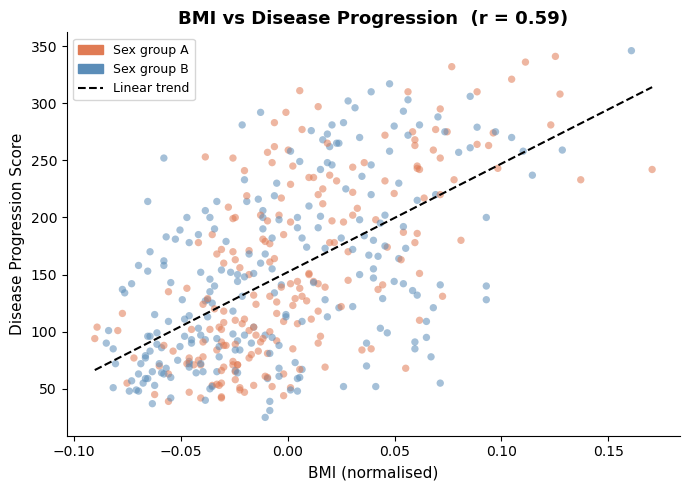

Saved: plot2_bmi_scatter.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

# Colour points by sex (sex column: positive values = one group, negative = other)
colours = ['#E07B54' if s > 0 else '#5B8DB8' for s in df['sex']]

ax.scatter(df['bmi'], df['disease_progression'], c=colours, alpha=0.55, s=28, edgecolors='none')

# Trend line
z = np.polyfit(df['bmi'], df['disease_progression'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['bmi'].min(), df['bmi'].max(), 200)
ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Linear trend')

legend_patches = [
    mpatches.Patch(color='#E07B54', label='Sex group A'),
    mpatches.Patch(color='#5B8DB8', label='Sex group B'),
    plt.Line2D([0], [0], color='k', linestyle='--', label='Linear trend'),
]
ax.legend(handles=legend_patches, fontsize=9)

corr = df[['bmi', 'disease_progression']].corr().iloc[0, 1]
ax.set_title(f'BMI vs Disease Progression  (r = {corr:.2f})', fontsize=13, fontweight='bold')
ax.set_xlabel('BMI (normalised)', fontsize=11)
ax.set_ylabel('Disease Progression Score', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot2_bmi_scatter.png', dpi=150)
plt.show()
print('Saved: plot2_bmi_scatter.png')

### Plot 3 — Correlation Heatmap (all features vs target)

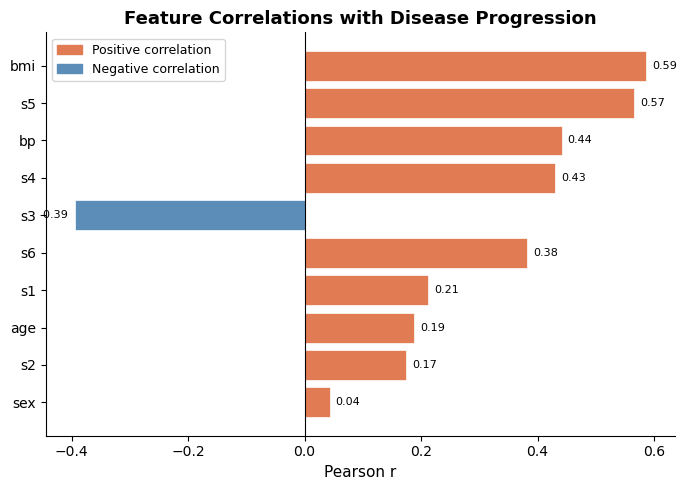

Saved: plot3_correlation_bar.png


In [10]:
# Sort features by absolute correlation with target
corr_series = df.corr()['disease_progression'].drop('disease_progression')
corr_sorted = corr_series.reindex(corr_series.abs().sort_values(ascending=True).index)

colours_bar = ['#E07B54' if v >= 0 else '#5B8DB8' for v in corr_sorted]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colours_bar, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)

# Annotate bar values
for bar, val in zip(bars, corr_sorted.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

pos_patch = mpatches.Patch(color='#E07B54', label='Positive correlation')
neg_patch = mpatches.Patch(color='#5B8DB8', label='Negative correlation')
ax.legend(handles=[pos_patch, neg_patch], fontsize=9)

ax.set_title('Feature Correlations with Disease Progression', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson r', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot3_correlation_bar.png', dpi=150)
plt.show()
print('Saved: plot3_correlation_bar.png')

---
## 5. Summary Write-Up

### What I found

The diabetis dataset contains **442 patients** with 10 normalised 
physiological features and a continuous outcome: disease progression one year 
after baseline measurement. The target score ranges from 25 to 346 with a 
mean of ~152, and its distribution is roughly bell-shaped with a slight right 
skew, meaning a minority of patients deteriorated significantly more than 
average.

The strongest positive correlates with disease progression are **s5** (a log 
transformed serum measurement, likely triglycerides), **bmi**, and **bp** 
(blood pressure). The **s1** feature (likely total cholesterol) shows a 
*negative* correlation, which is counterintuitive but can reflect that high 
HDL ("good" cholesterol) is associated with better outcomes. The scatter plot 
confirms a visible upward trend between BMi and disease severity; patients 
with higher BMI tend to have worse 1 year outcomes, though there is 
substantial scatter, showing that BMI alone cannot predict progression
reliably.

### What surprised me

What surprised me is how often real clinical data refuses to behave like
clean textbook examples. In the diabetes progression dataset, it is striking
that very ordinary measures like BMI and blood pressure carry so much
predictive signal, while some serum features go in "unexpected" directions
once you account for HDL vs LDL, treatment, and noise. It is also common to
see that the same BMI or lipid level maps to different risk patterns in 
different subgroups (for example, by sex), and that how a parameter changes
over time can matter as much as its baseline value. Perhaps the biggest 
surprise is that even with clear correlations, there is still a lot of 
scatter: models can highlight trends, but individual patient outcomes 
remain uncertain, which is exactly why simple risk scores and pretty plots 
have to be used carefully in real clinical decisions. 


### What I would explore next

1. **Bin the target** into Low / Medium / High categories and treat it as a
classification problem ; this is the setup used on Day 7's classifier.
2. **Pairplot** (seaborn) to visualise interactions between the top 4 
features simultaneously.
3. **Check if sex moderates the BMI–outcome relationship** — the scatter 
plot hints at different cluster positions but needs a proper grouped analysis.

    